그래프의 구성요소
- Figure: 그림 전체
- Axes: 그림 내부의 좌표축을 의미하며, 개별 그림을 의미
- Line: 선 그래프에서 선
- Markers: 점 그래프에서 마커
- Legend: 범례
- Title: 제목
- Grid: 격자
- Spines: 윤곽선
- X axis label: x축 레이블
- Y axis label: y축 레이블
- Major tick: 메인 눈금
- Major tick label: 메인 눈금 레이블
- Minor tick: 서브 눈금
- Minor tick label: 서브 눈금 레이블

### 그래프 종류
- plot(선)
- bar(수직 막대)
- barh(수평 막대)
- box(박스 플롯)
- kde(커널 밀도 그래프)
- area(면적 그래프)
- pie(파이 그래프)
- hexbin(고밀도 산점도 그래프)
- scatter(산점도)
- hist(히스토그램)
- sns.heatmap(히트맵)

In [243]:
import matplotlib.pyplot as plt
import seaborn as sns, pandas as pd

df = sns.load_dataset('penguins')
df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
...,...,...,...,...,...,...,...
339,Gentoo,Biscoe,NaN,NaN,NaN,NaN,NaN
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [244]:
df.dtypes

species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
dtype: object

In [206]:
df.isna().sum()

species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
dtype: int64

In [207]:
# 결축치 있는 값만 출력
# reduce 형 연산 축이 없어지고 크기가 줄어드는
# sum, mean, std, min, max, argmin
df[df.isnull().any(axis=1)] # any = or / all = and
# cond = df.isnull().sum(axis=1) > 0
# df[cond]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


In [208]:
na_df = df.dropna()
na_df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,Female
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,Female
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,Male
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,Female


In [209]:
a = df.groupby('island')
a.groups.keys()
a.get_group('Torgersen').reset_index(drop=True).head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [210]:
# pandas group 다양한 인터페이스
# 1. group['컬럼이름'].reduce() -> 전형적인 그룹 처리 방법
# 2. 리스트/딕셔너리로 생각해도된다.
a = [('asdf',1),('qwer',2),('zxcv',3)] # 튜플-리스트 연합은 딕셔너리로 변환가능
# print(a)

b = dict(list(list(df.groupby('species'))))
# print(b['Adelie'])

for key, value in b.items():
    b[key] = value['body_mass_g'].mean()
pd.Series(b)

Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
dtype: float64

In [211]:
df.groupby('species').apply(lambda x:x['body_mass_g'].mean(), include_groups=False)

species
Adelie       3700.662252
Chinstrap    3733.088235
Gentoo       5076.016260
dtype: float64

In [212]:
df[['species','island']].value_counts()

species    island   
Gentoo     Biscoe       124
Chinstrap  Dream         68
Adelie     Dream         56
           Torgersen     52
           Biscoe        44
Name: count, dtype: int64

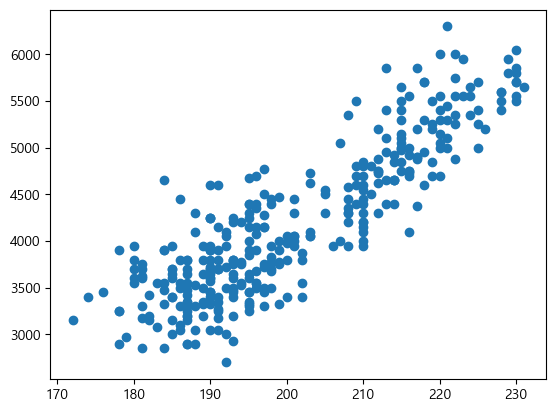

In [213]:
plt.scatter(df['flipper_length_mm'], df['body_mass_g']);

In [214]:
s_df = df.groupby('species')['body_mass_g'].mean().reset_index()
s_df

,species,body_mass_g
0,Adelie,3700.662252
1,Chinstrap,3733.088235
2,Gentoo,5076.016260


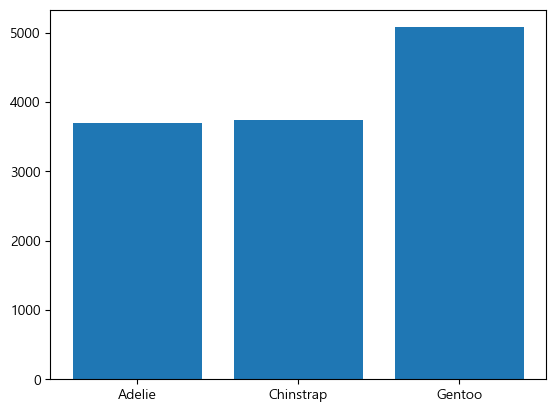

In [215]:
df_group = df.groupby('species')['body_mass_g'].mean().reset_index()
plt.bar(x=df_group['species'], height=df_group['body_mass_g'])
plt.show()

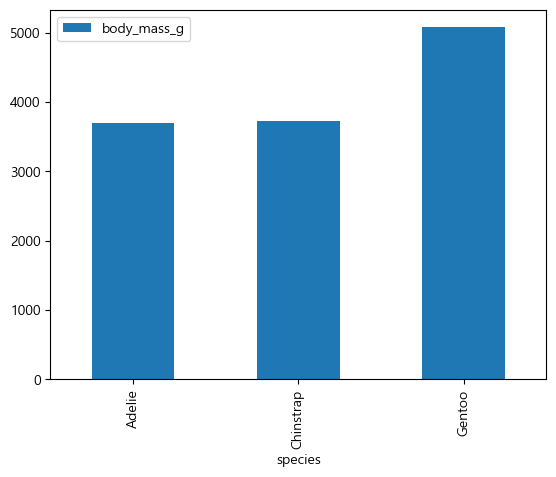

In [216]:
# df_group.plot(x='species', y='body_mass_g', kind='bar');
df_group.plot.bar(x='species', y='body_mass_g');

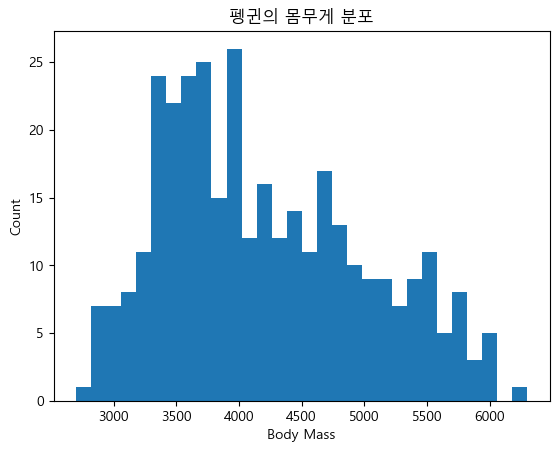

In [217]:
plt.rc('font', family='Malgun Gothic')
plt.hist(df['body_mass_g'], bins=30)
plt.xlabel('Body Mass')
plt.ylabel('Count')
plt.title('펭귄의 몸무게 분포')
plt.show()

- stateless API (objected-based): 내가 지정한 figure, 내가 지정한 axes에 그림을 그리는 방법
- stateful API (state-based): 현재의 figure, 현재의 axes에 그림을 그리는 방법

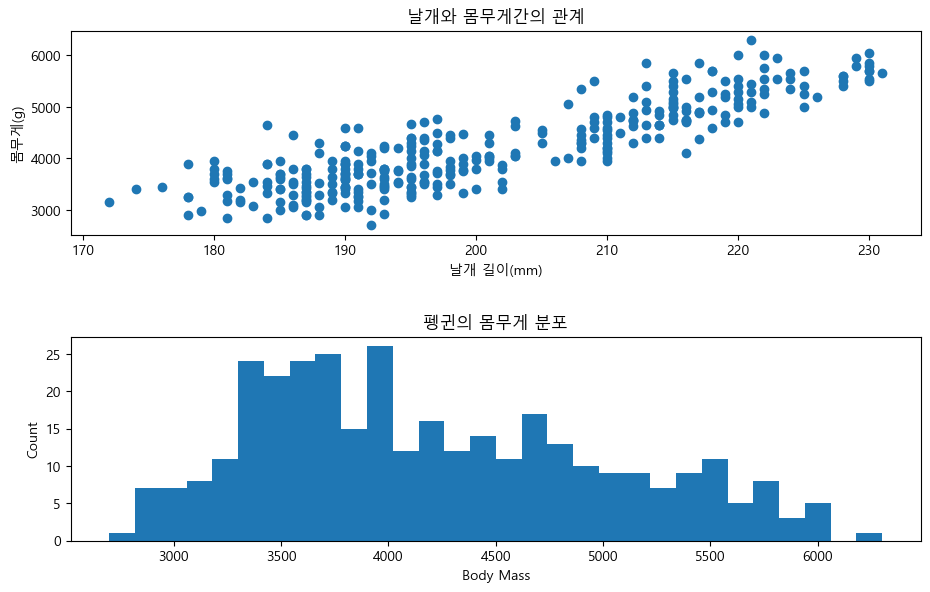

In [218]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))

# 첫번째 그림
axes[0].scatter(df['flipper_length_mm'], df['body_mass_g'])
axes[0].set_xlabel('날개 길이(mm)')
axes[0].set_ylabel('몸무게(g)')
axes[0].set_title('날개와 몸무게간의 관계')

# 두번째 그림
axes[1].hist(df['body_mass_g'], bins=30)
axes[1].set_xlabel('Body Mass')
axes[1].set_ylabel('Count')
axes[1].set_title('펭귄의 몸무게 분포')

# 간격 조정
plt.subplots_adjust(left=0.1,
                    right=0.95,
                    bottom=0.1,
                    top=0.95,
                    wspace=0.5,
                    hspace=0.5)

plt.show()

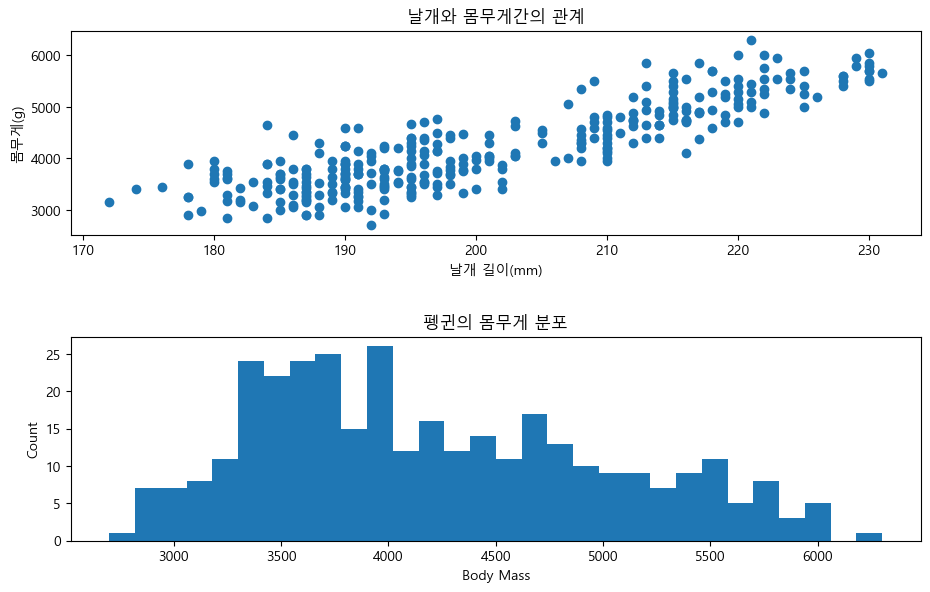

In [219]:
plt.figure(figsize=(10, 6))

# 첫번째 그림
plt.subplot(2, 1, 1)
plt.scatter(df['flipper_length_mm'], df['body_mass_g'])
plt.xlabel('날개 길이(mm)')
plt.ylabel('몸무게(g)')
plt.title('날개와 몸무게간의 관계')

# 두번째 그림
plt.subplot(2, 1, 2)
plt.hist(df['body_mass_g'], bins=30)
plt.xlabel('Body Mass')
plt.ylabel('Count')
plt.title('펭귄의 몸무게 분포')

# 간격 조정
plt.subplots_adjust(left=0.1,
                    right=0.95,
                    bottom=0.1,
                    top=0.95,
                    wspace=0.5,
                    hspace=0.5)

plt.show()

In [220]:
import seaborn as sns

df = sns.load_dataset('diamonds')
df

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


In [221]:
# 범주형 데이터
# 1. 문자형
# 2. 카테고리형 (특별 데이터)
df['cut2'] = df['cut'].astype('str')
df['cut2'].dtypes
df['cut2']

0            Ideal
1          Premium
2             Good
3          Premium
4             Good
           ...    
53935        Ideal
53936         Good
53937    Very Good
53938      Premium
53939        Ideal
Name: cut2, Length: 53940, dtype: object

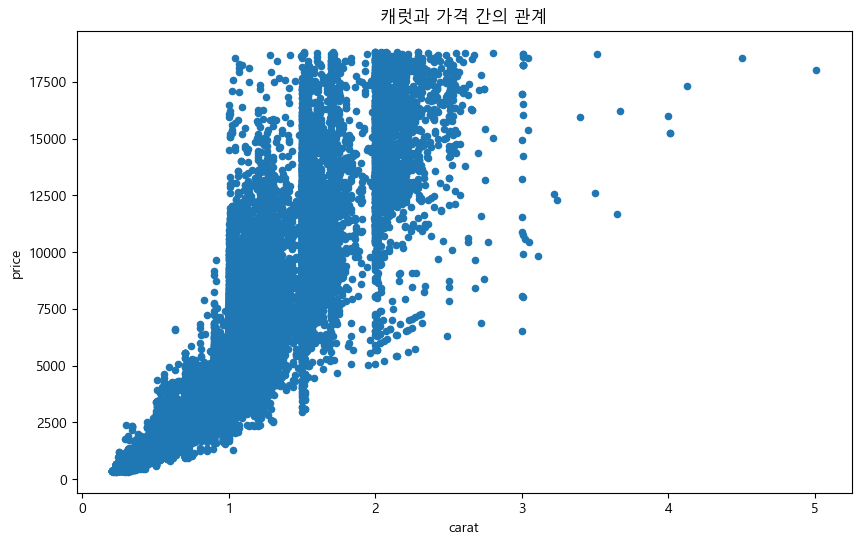

In [222]:
plt.rc('font', family='Malgun Gothic')
df.plot.scatter(x='carat', y='price', figsize=(10, 6), title='캐럿과 가격 간의 관계')
plt.show()

In [223]:
r = dict(list(zip(df['cut2'].value_counts().index, range(5))))
df['cut3'] = df['cut'].replace(r)
df['cut3']
# df['cut2'].astype('category')

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_2908\802126751.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['cut3'] = df['cut'].replace(r)
C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_2908\802126751.py:2: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  df['cut3'] = df['cut'].replace(r)


0        0
1        1
2        3
3        1
4        3
        ..
53935    0
53936    3
53937    2
53938    1
53939    0
Name: cut3, Length: 53940, dtype: category
Categories (5, int64): [0, 1, 2, 3, 4]

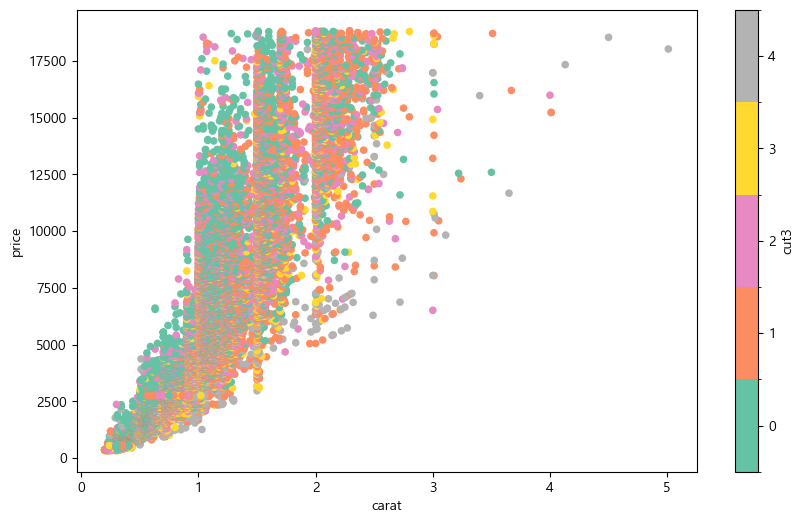

In [224]:
df.plot.scatter(x='carat', y='price', c='cut3', cmap='Set2', figsize=(10, 6))
plt.show()

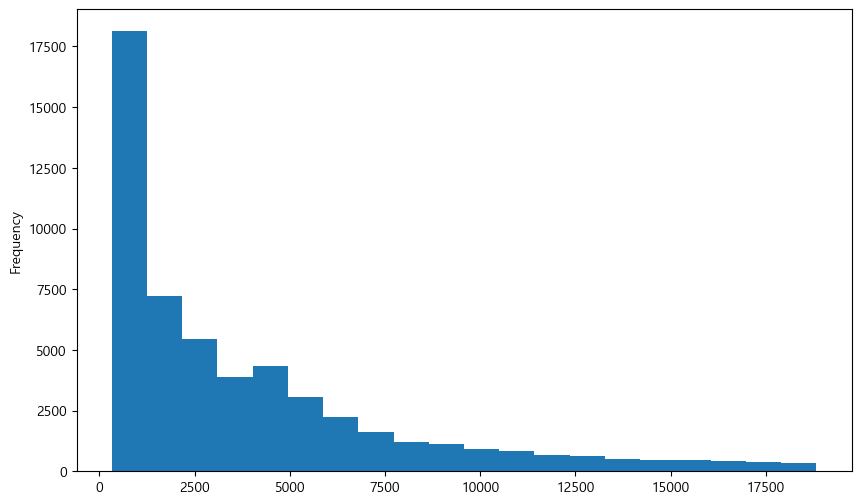

In [225]:
df['price'].plot.hist(figsize=(10, 6), bins=20)
plt.show()

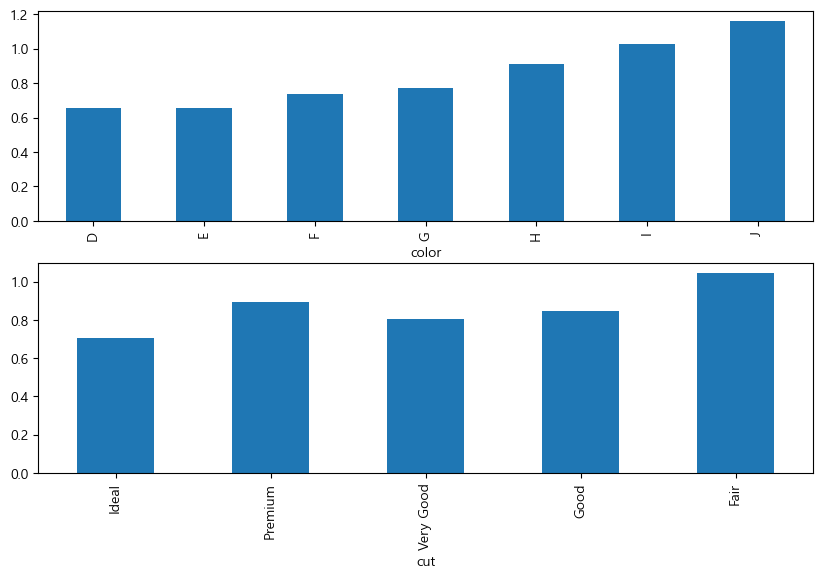

In [226]:
plt.subplot(2,1,1)
df.groupby('color', observed=True)['carat'].mean().plot.bar(figsize=(10, 6),)

plt.subplot(2,1,2)
df.groupby('cut', observed=True)['carat'].mean().plot.bar(figsize=(10, 6),)
plt.show()

0        (0.195, 1.162]
1        (0.195, 1.162]
2        (0.195, 1.162]
3        (0.195, 1.162]
4        (0.195, 1.162]
              ...      
53935    (0.195, 1.162]
53936    (0.195, 1.162]
53937    (0.195, 1.162]
53938    (0.195, 1.162]
53939    (0.195, 1.162]
Name: carat_band, Length: 53940, dtype: category
Categories (5, interval[float64, right]): [(0.195, 1.162] < (1.162, 2.124] < (2.124, 3.086] < (3.086, 4.048] < (4.048, 5.01]]


C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_2908\2273485260.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_carat_band_price = df.groupby('carat_band')['price'].mean().reset_index()


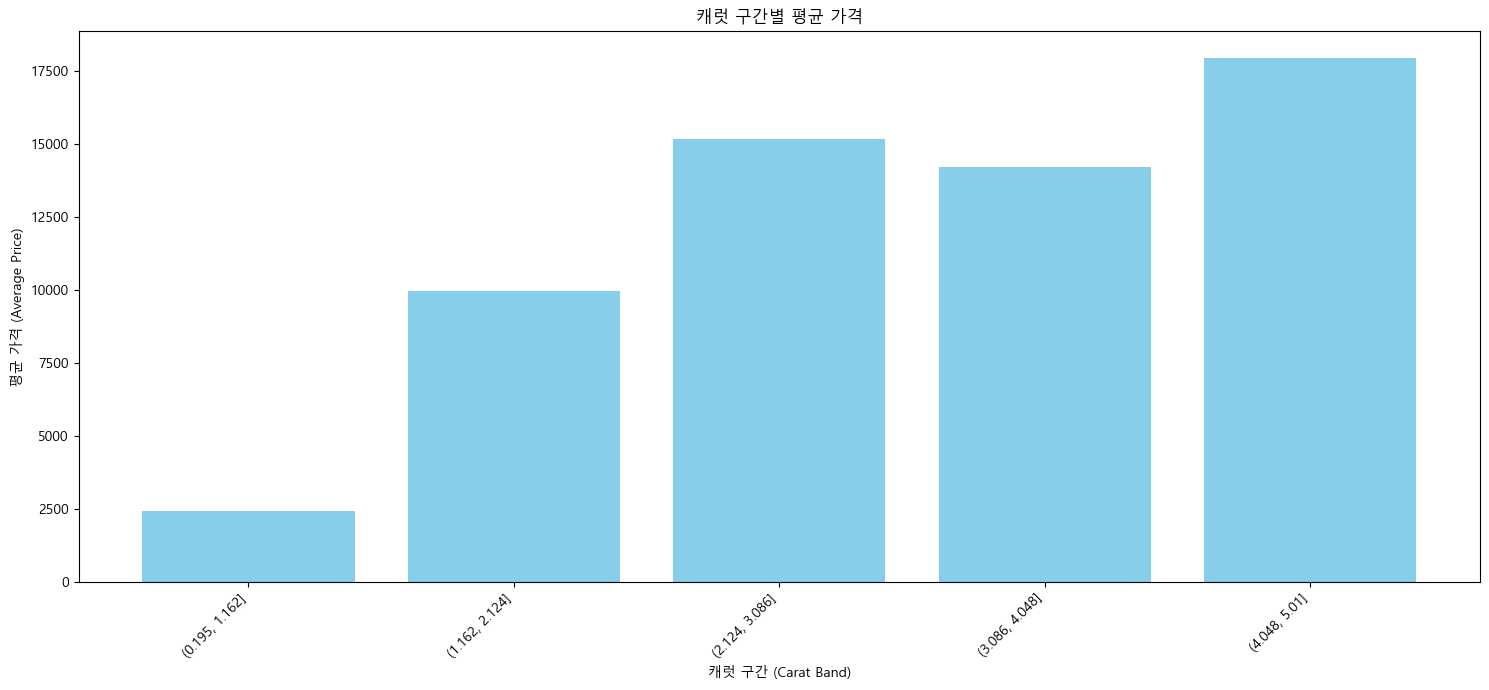

In [227]:
df_carat_price = df.groupby('carat')['price'].mean().reset_index()

plt.rc('font', family='Malgun Gothic') # 한글 폰트 설정 (필요한 경우)

# 캐럿 구간별 평균 가격 막대 그래프 (더 유용할 수 있음)
# 캐럿을 구간(bins)으로 나누어 시각화하는 것이 더 보기 좋을 수 있습니다.
df['carat_band'] = pd.cut(df['carat'], bins=5) # 10개 구간으로 나눔
df_carat_band_price = df.groupby('carat_band')['price'].mean().reset_index()

print(df['carat_band'])

plt.figure(figsize=(15, 7))
plt.bar(x=df_carat_band_price['carat_band'].astype(str), height=df_carat_band_price['price'], color='skyblue')
plt.xlabel('캐럿 구간 (Carat Band)')
plt.ylabel('평균 가격 (Average Price)')
plt.title('캐럿 구간별 평균 가격')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_2908\3819501536.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_price = df.groupby('carat_group')['price'].mean()


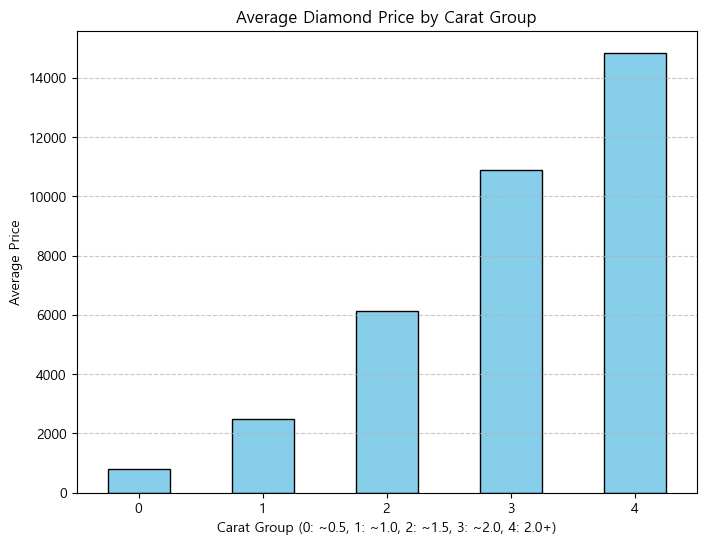

In [228]:
# 2. 캐럿 구간 설정
# 구간 경계: 0, 0.5, 1.0, 1.5, 2.0, 그리고 그 이상(float('inf'))
bins = [0, 0.5, 1.0, 1.5, 2.0, float('inf')]

# 구간에 부여할 라벨 (0, 1, 2, 3, 4)
labels = [0, 1, 2, 3, 4]

# 3. pd.cut을 활용한 구간 분류
df['carat_group'] = pd.cut(df['carat'], bins=bins, labels=labels, right=False)

# 4. 구간별 평균 가격 계산
group_price = df.groupby('carat_group')['price'].mean()

# 5. Bar 그래프 그리기
plt.figure(figsize=(8, 6))
group_price.plot(kind='bar', color='skyblue', edgecolor='black')

plt.title('Average Diamond Price by Carat Group')
plt.xlabel('Carat Group (0: ~0.5, 1: ~1.0, 2: ~1.5, 3: ~2.0, 4: 2.0+)')
plt.ylabel('Average Price')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [229]:
df.groupby(['carat_group','cut'])['price'].mean()

C:\Users\Win11Pro\AppData\Local\Temp\ipykernel_2908\209686408.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['carat_group','cut'])['price'].mean()


carat_group  cut      
0            Ideal          830.932786
             Premium        817.474740
             Very Good      698.936463
             Good           694.350790
             Fair           894.575221
1            Ideal         2452.255276
             Premium       2482.103874
             Very Good     2595.710223
             Good          2530.811837
             Fair          2291.455882
2            Ideal         6865.976744
             Premium       5896.290992
             Very Good     6093.888812
             Good          5280.734068
             Fair          4367.900407
3            Ideal        11700.735140
             Premium      10959.968992
             Very Good    10965.468615
             Good          9522.396714
             Fair          8005.297619
4            Ideal        15524.324219
             Premium      14908.467073
             Very Good    15103.920000
             Good         14598.451163
             Fair         11875.324841
Na

In [230]:
df = sns.load_dataset('titanic')
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


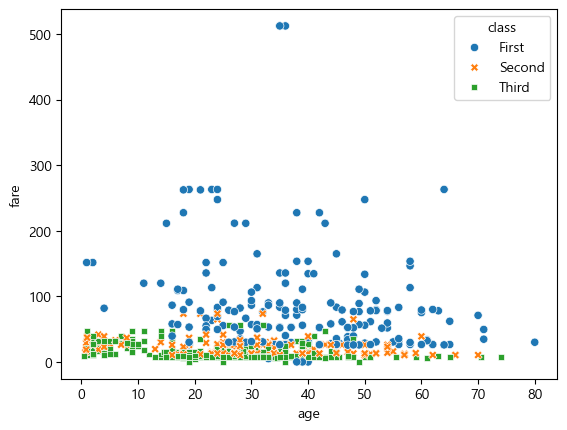

In [231]:
sns.scatterplot(data=df, x='age', y='fare', hue='class', style='class')
plt.show()

In [232]:
df_pivot = df.pivot_table(index='class',
                          columns='sex',
                          values='survived',
                          aggfunc='mean',
                          observed=False)
df_pivot

sex,female,male
class,,
First,0.968085,0.368852
Second,0.921053,0.157407
Third,0.500000,0.135447


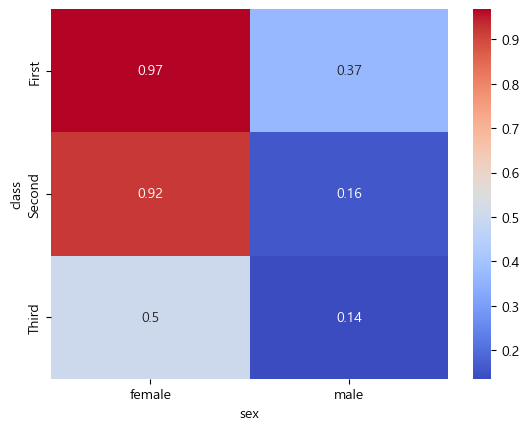

In [233]:
sns.heatmap(df_pivot, annot=True, cmap='coolwarm')
plt.show()

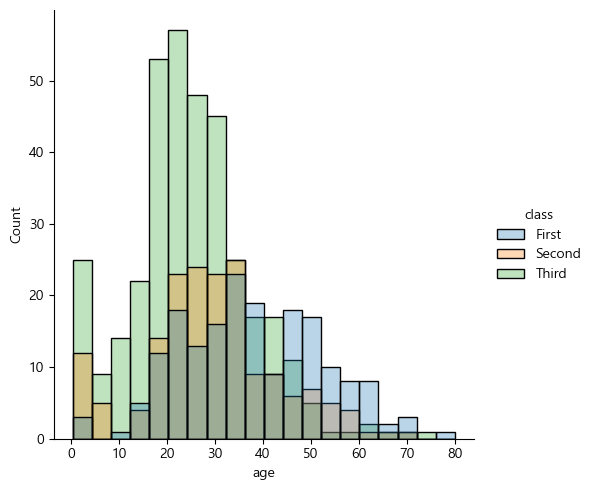

In [234]:
sns.displot(data=df, x='age', hue='class', kind='hist', alpha=0.3)
plt.show()

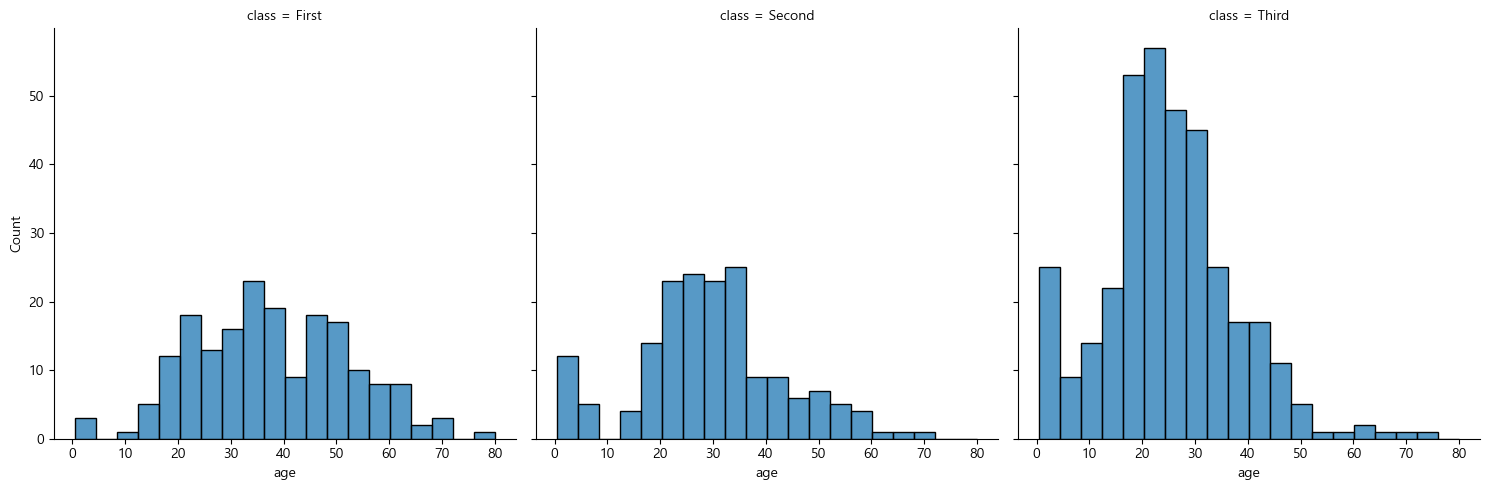

In [235]:
sns.displot(data=df, x='age', col='class', kind='hist')
plt.show()

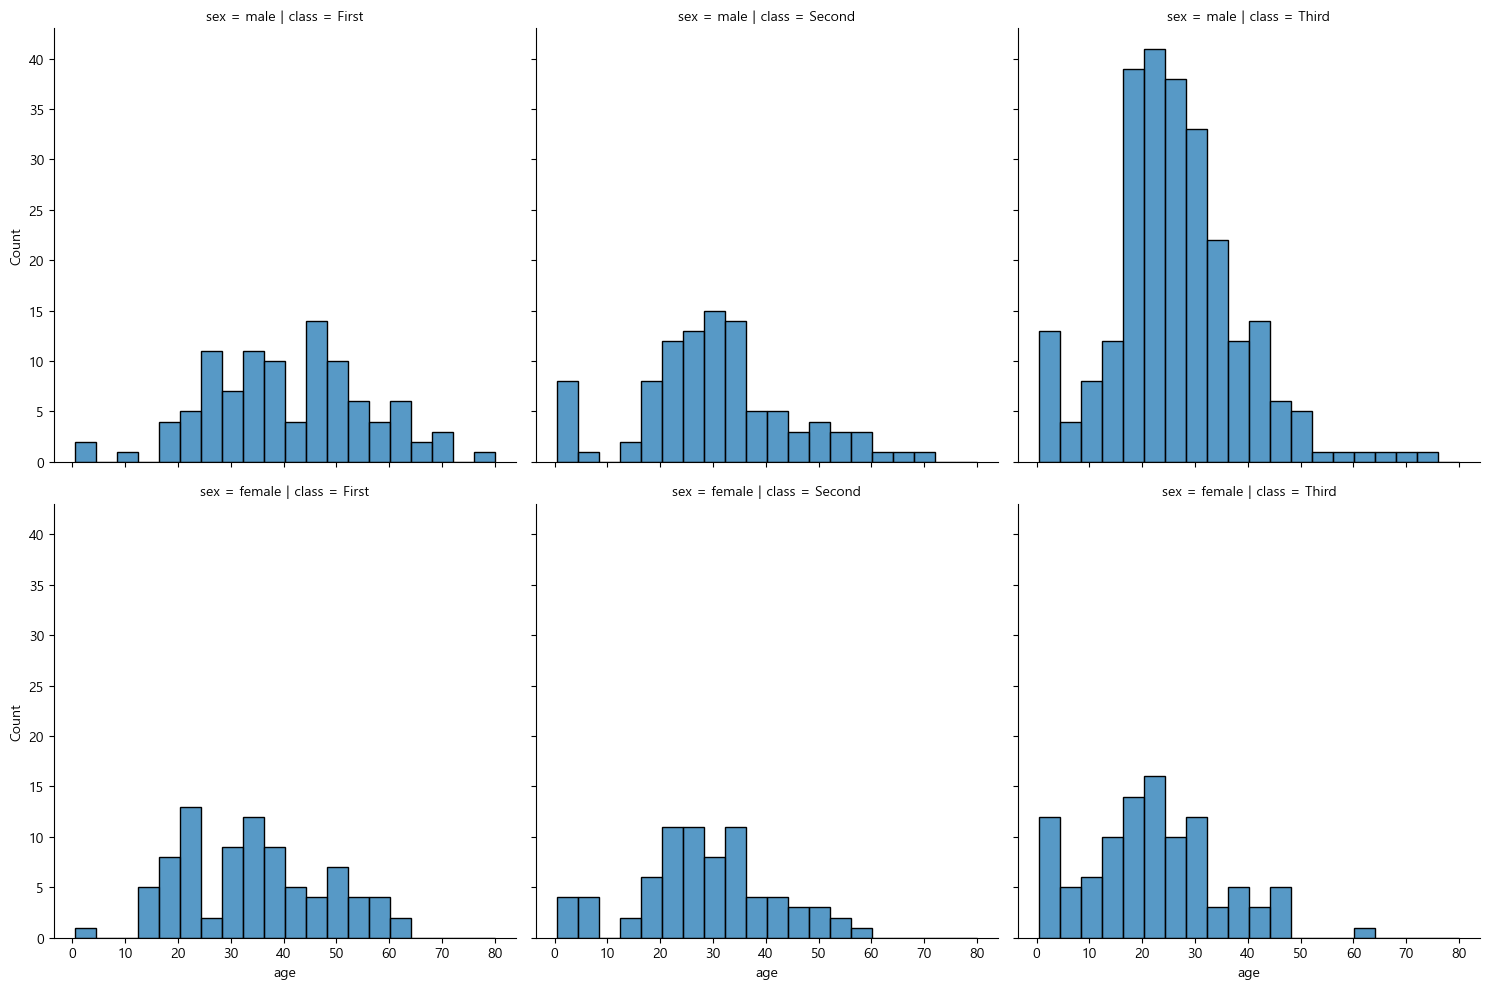

In [236]:
sns.displot(data=df, x='age', col='class', row='sex', kind='hist')
plt.show()

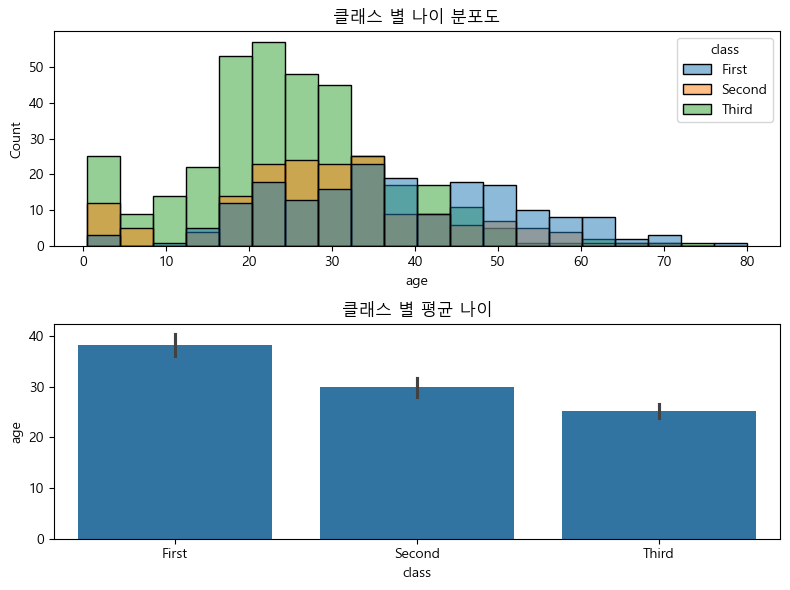

In [237]:
plt.rc('font', family='Malgun Gothic')

g, axes = plt.subplots(2, 1, figsize=(8, 6))

sns.histplot(data=df, x='age', hue='class', ax=axes[0])
sns.barplot(data=df, x='class', y='age', ax=axes[1])

axes[0].set_title('클래스 별 나이 분포도')
axes[1].set_title('클래스 별 평균 나이')

g.tight_layout()
plt.show()

In [ ]:
# lamda
def func(a,b): return a + b
a = func
print(a(1,2))

def calc(f,a,b): return f(a,b)
print(calc(func,1,2))
print(calc(lambda x, y : x+y, 1, 2))
print((lambda x, y : x + y)(1,2))

a = [{'k':30},{'k':40},{'k':20}]
print(a)
a.sort(key = lambda x: x['k'])
print(a)

3
3
3
3
[{'k': 30}, {'k': 40}, {'k': 20}]
[{'k': 20}, {'k': 30}, {'k': 40}]


In [ ]:
print() # => None == void
print(None, '\n')
print(print(None))


None 

None
None
